# 02 — Landscape embedding

Build a 2D landscape: **cell-type-like axis (x)** from a late-cell scaffold + **progress axis (y)**.

**Paper:** y = inferred developmental age after ATAC integration.  
**Demo:** no age labels → `demo_time` = first multiview spectral coordinate (sign-aligned with depth). Algorithm is the same; only y differs.


In [1]:
from pathlib import Path
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import sparscit as sc

sc.set_defaults(n_jobs=-1, figsize=(6, 5))

cached = Path("../epigenetic_landscape_analysis_notebooks/demos/data") / "demo_embedded.h5ad"

if cached.is_file():
    adata = ad.read_h5ad(cached)
    print("loaded cache", cached, adata.shape)


loaded cache ../epigenetic_landscape_analysis_notebooks/demos/data/demo_embedded.h5ad (4970, 21925)


In [2]:
depth = (
    adata.obs["acet_total_counts"].to_numpy()
    + adata.obs["meth_total_counts"].to_numpy()
)
# Proxy developmental axis for the tutorial
adata.obs["demo_time"] = adata.obsm["X_multi_spectral"][:, 0]
if np.corrcoef(adata.obs["demo_time"].to_numpy(), depth)[0, 1] < 0:
    adata.obs["demo_time"] = -adata.obs["demo_time"].to_numpy()


In [3]:
# 1) Late cells → leiden → hierarchical scaffold (leaf order)
tau = np.quantile(adata.obs["demo_time"], 0.6)
late = adata[adata.obs["demo_time"].to_numpy() > tau].copy()
sc.gr.knn(late, "X_multi_spectral", n_neighbors=15)
sc.gr.leiden(late, resolution=0.8, random_seed=0)
sc.gr.community_hierarchy(late, "leiden")
scaffold = sc.adv.create_landscape_scaffold(late)
print(scaffold, "late cells:", late.n_obs)


Scaffold on 1988 cells late cells: 1988


In [6]:
# 2) Fine metacells on full data, then landscape (short UMAP polish)
sc.gr.leiden(adata, resolution=3.0, random_seed=0)
sc.em.landscape(
    adata,
    scaffold,
    y_key="demo_time",
    embedding_key="X_multi_spectral",
    community_key="leiden",
    umap_epochs=3,
)
print("X_landscape", adata.obsm["X_landscape"].shape)


  0%|          | 0/9 [00:00<?, ?it/s]

Info: Creating layout using 8 leaf clusters
X_landscape (4970, 2)


/home/aleksander-work/Dokument/work11/scit-package/venv/lib/python3.12/site-packages/umap/umap_.py:2021: UserWarning: precomputed_knn[2] (knn_search_index) is not an NNDescent object: transforming new data with transform will be unavailable.
  warn(


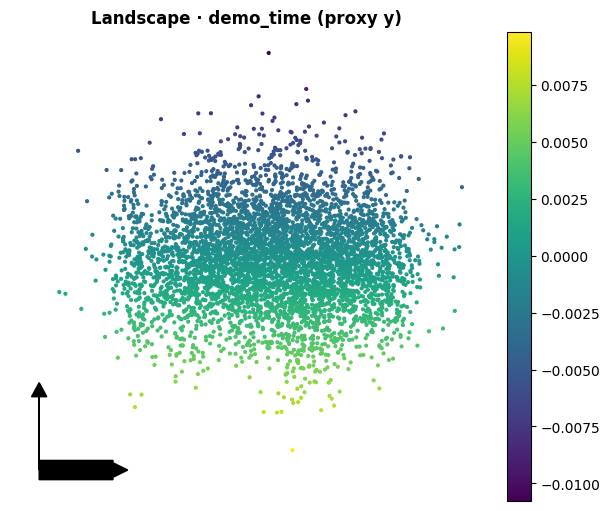

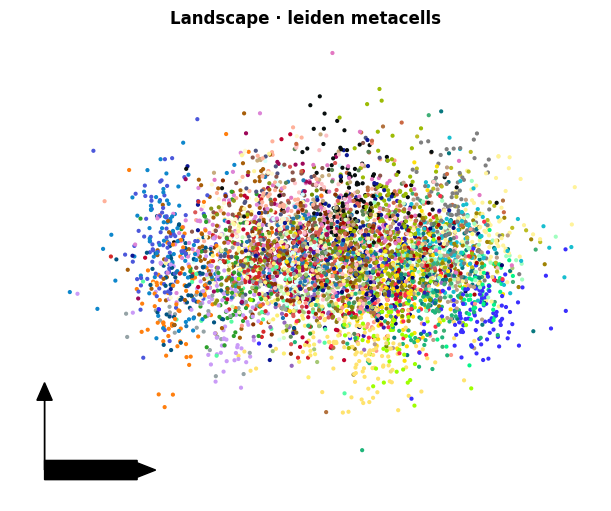

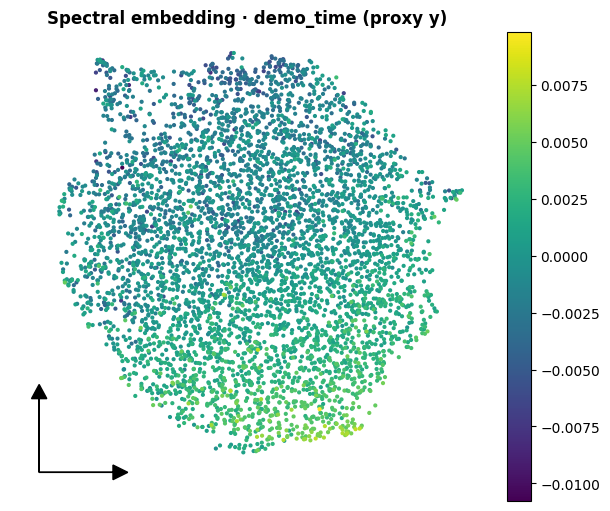

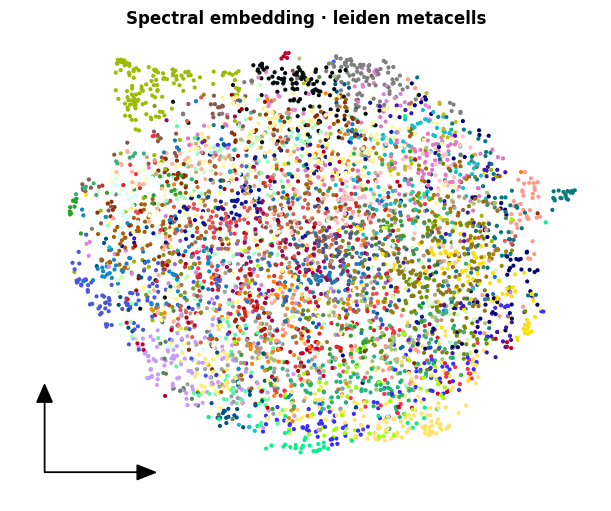

In [11]:
sc.pl.embedding2d(
    adata, "X_landscape", "demo_time", size=4, title="Landscape · demo_time (proxy y)"
)
plt.show()
sc.pl.embedding2d(
    adata, "X_landscape", "leiden", size=4, title="Landscape · leiden metacells"
)
sc.pl.embedding2d(
    adata, "X_umap", "demo_time", size=4, title="Spectral embedding · demo_time (proxy y)"
)
sc.pl.embedding2d(
    adata, "X_umap", "leiden", size=4, title="Spectral embedding · leiden metacells"
)
plt.show()


In [12]:

out = Path("../epigenetic_landscape_analysis_notebooks/demos/data") / "demo_landscape.h5ad"

adata.write_h5ad(out, compression="gzip")
print("wrote", out.resolve())


wrote /home/aleksander-work/Dokument/work11/epigenetic_landscape_analysis_notebooks/demos/data/demo_landscape.h5ad
